<h1><span style="color:black; font-weight:bold"><u><center>Rocket League Data Analysis and Predictive Pipeline</center></u></span></h1>

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from matplotlib.animation import FuncAnimation
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
import hdbscan
import math
import os

In [2]:
os.environ["OMP_NUM_THREADS"] = "5"

def safe_zscore(x):
    std = x.std()
    if std == 0 or pd.isna(std):
        return 0
    return (x - x.mean()) / std

def merge_ranks(df):
    temp_df = df[(df['rank'] != 'potential-smurfs-enaka01dhi') & (df['rank'] != '.ipynb_checkpoints')].copy()
    for i in temp_df.index:
        temp_rank = temp_df.loc[i, 'rank']
        if temp_rank != 'supersonic-legend':
            temp_rank = temp_rank[:-2]
            temp_df.loc[i, 'rank'] = temp_rank
    return temp_df

In [3]:
master_df = pd.read_csv('replay_csvs/master_replays.csv')
master_df = master_df.drop(columns=['team name'])
features = master_df.select_dtypes(include=['number']).columns.drop('smurf')

master_df = merge_ranks(master_df)

numeric_df = master_df.select_dtypes(include=['number'])
meta_df = master_df.select_dtypes(exclude=['number'])

In [4]:
for i in meta_df.columns:
    print(i)

replay_id
playlist
rank
color
player name
platform
player id
car name
demos taken


In [5]:
for i in master_df.columns:
    print(i)

replay_id
playlist
rank
color
player name
platform
player id
car id
car name
game duration
score
goals
assists
saves
shots
shots conceded
goals conceded
goals conceded while last defender
shooting percentage
bpm
avg boost amount
amount collected
amount collected big pads
amount collected small pads
count collected big pads
count collected small pads
amount stolen
amount stolen big pads
amount stolen small pads
count stolen big pads
count stolen small pads
0 boost time
100 boost time
amount used while supersonic
amount overfill total
amount overfill stolen
avg speed
total distance
time slow speed
percentage slow speed
time boost speed
percentage boost speed
time supersonic speed
percentage supersonic speed
time on ground
percentage on ground
time low in air
percentage low in air
time high in air
percentage high in air
time powerslide
avg powerslide time
count powerslide
time most back
time most forward
avg distance to ball
avg distance to ball has possession
avg distance to ball no poss

<h2><span style="color:blue; font-weight:bold"><u>t-SNE Analysis and Clustering</u></span></h2>
<p><span style="color:green; font-weight:bold">t-SNE dimensionality reduction is run on the data to visualize behavioral groups and attempt to create influential clustering calculations</span></p>

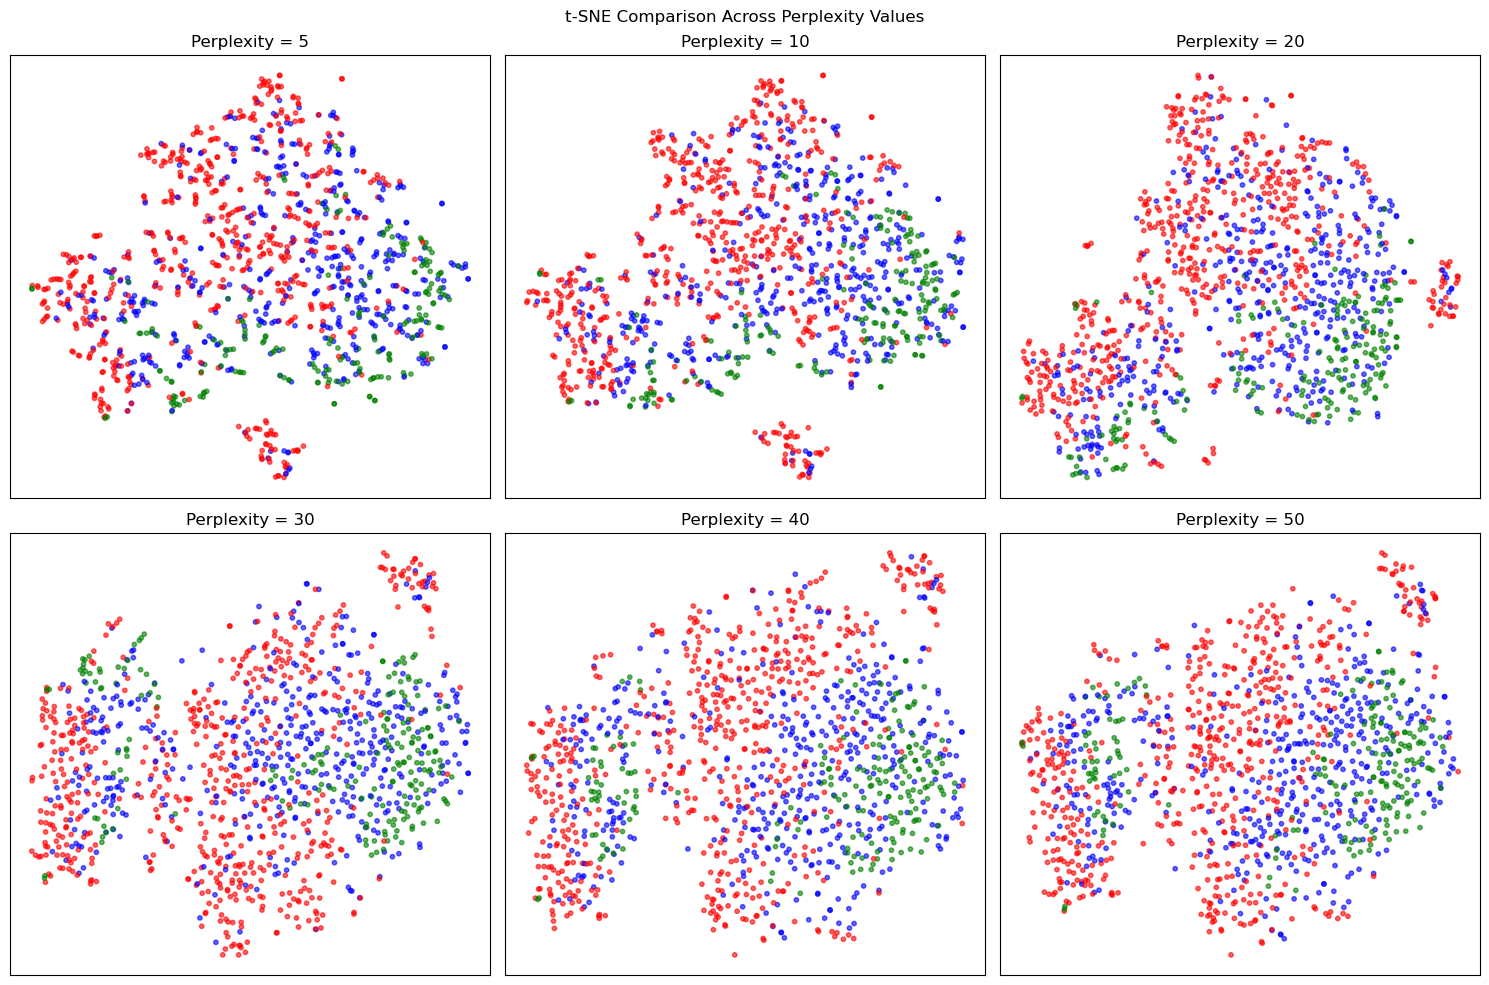

In [6]:
color_map = {
    'bronze': 'red',
    'silver': 'red',
    'gold': 'red',
    'platinum': 'blue',
    'diamond': 'blue',
    'champion': 'blue',
    'grand-champion': 'green',
    'supersonic-legend': 'green'
}

point_colors = master_df['rank'].map(color_map)

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)

lof = LocalOutlierFactor(n_neighbors=20)
lof.fit(numeric_scaled)
lof_scores = -lof.negative_outlier_factor_

perplexities = [5, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, p in zip(axes.flatten(), perplexities):
    coords = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42
    ).fit_transform(numeric_scaled)

    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=point_colors,
        s=10,
        alpha=0.6
    )

    ax.set_title(f"Perplexity = {p}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("t-SNE Comparison Across Perplexity Values")
plt.tight_layout()
plt.show()

In [7]:
random_states = [0, 21, 42, 84, 126]

results = []

for p in perplexities:
    vals = []
    for rs in random_states:
        coords = TSNE(n_components=2, perplexity=p, random_state=rs).fit_transform(numeric_scaled)
        vals.append(trustworthiness(numeric_scaled, coords, n_neighbors=10))
    results.append((p, np.mean(vals), np.std(vals)))

for r in results:
    print('Perplexity: ', r[0], ', Trustworthiness: ', r[1], 'Standard Dev.: ', r[1])

Perplexity:  5 , Trustworthiness:  0.9320576252127635 Standard Dev.:  0.9320576252127635
Perplexity:  10 , Trustworthiness:  0.9427254522909141 Standard Dev.:  0.9427254522909141
Perplexity:  20 , Trustworthiness:  0.9453047107058229 Standard Dev.:  0.9453047107058229
Perplexity:  30 , Trustworthiness:  0.9466895924953211 Standard Dev.:  0.9466895924953211
Perplexity:  40 , Trustworthiness:  0.946855105168709 Standard Dev.:  0.946855105168709
Perplexity:  50 , Trustworthiness:  0.9474428587199017 Standard Dev.:  0.9474428587199017


<h3><span style="color:blue; font-weight:bold">Final t-SNE reduction</span></h3>
<p><span style="color:green; font-weight:bold">From the previous grid and the trustworthiness calculations, a perplexity value of 20 is deemed to be sufficient for final tSNE run.</span></p>

In [8]:
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)

numeric_coords = TSNE(n_components=2,perplexity=20,random_state=42).fit_transform(numeric_scaled)
tsne_df = pd.DataFrame(numeric_coords, columns=['tsne_1', 'tsne_2'], index=numeric_df.index)
master_tsne = pd.concat([meta_df, numeric_df, tsne_df],axis=1)

In [9]:
lof = LocalOutlierFactor(n_neighbors=20)
scores = -lof.fit_predict(numeric_scaled)

master_tsne['lof_score'] = lof.negative_outlier_factor_

<p><span style="color:green; font-weight:bold">tSNE is ran with a perplexity value of 20 and LOF scores of each data point are calculated. LOF scores will give another informative feature for prediction, by creating an identifier of low-neighboring-density anomalies.</span></p>

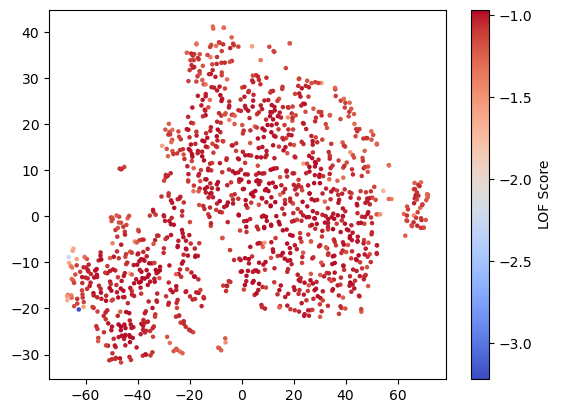

In [10]:
plt.scatter(tsne_df['tsne_1'], tsne_df['tsne_2'], 
            c=master_tsne['lof_score'], cmap='coolwarm', s=5)
plt.colorbar(label='LOF Score')
plt.show()

<h3><span style="color:blue; font-weight:bold">k-Means Clustering</span></h3>
<p><span style="color:green; font-weight:bold">Visualizations are created using the calculated t-SNE components. Using these coordinates, k-Means clustering of 5 is ran on the data to use as another informative feature for prediction.</span></p>

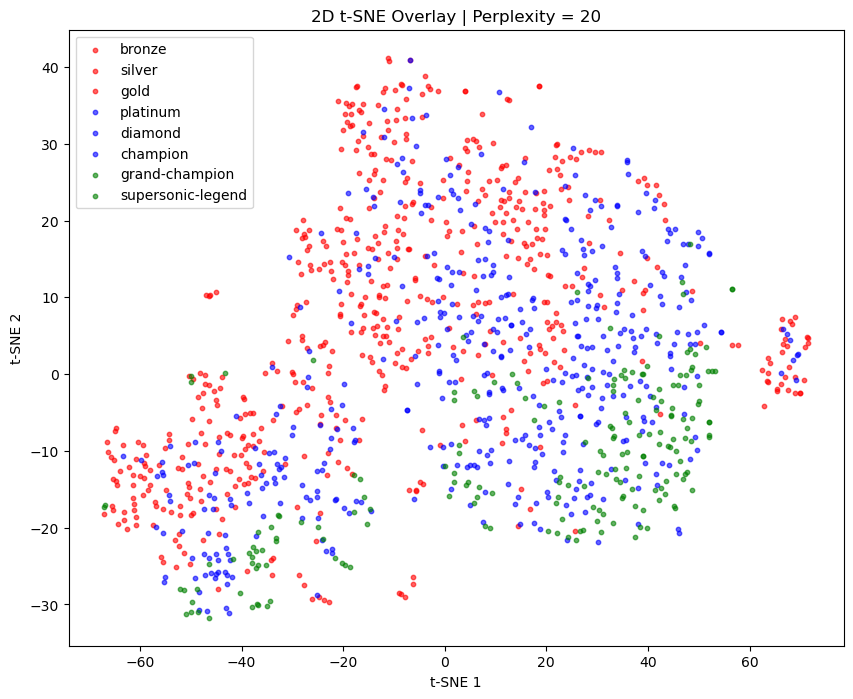

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

colors = {'bronze': 'red','silver': 'red','gold': 'red','platinum': 'blue',
        'diamond': 'blue', 'champion': 'blue','grand-champion': 'green', 'supersonic-legend': 'green'}

point_colors = master_tsne['rank'].map(colors).fillna('black')

for rank, color in colors.items():
    mask = master_tsne['rank'] == rank
    ax.scatter(
        numeric_coords[mask, 0],
        numeric_coords[mask, 1],
        c=color,
        label=rank,
        s=10,
        alpha=0.6
    )

ax.set_title(f"2D t-SNE Overlay | Perplexity = 20")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
plt.savefig("tsne_plot_2d.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


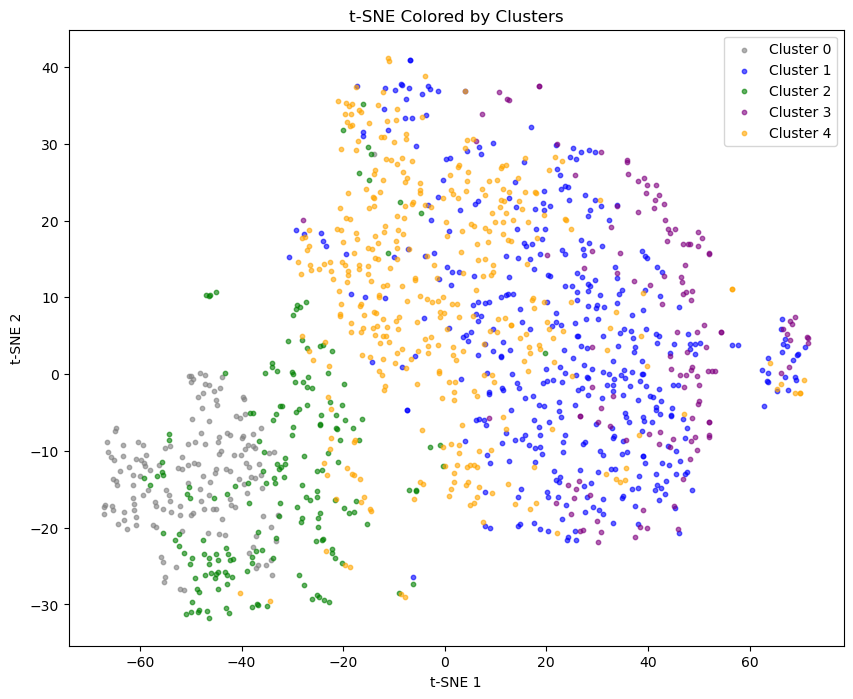

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
master_tsne['cluster'] = kmeans.fit_predict(numeric_df.values)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

colors = ['grey', 'blue', 'green', 'purple', 'orange']

for i, cluster_id in enumerate(sorted(master_tsne['cluster'].unique())):
    mask = master_tsne['cluster'] == cluster_id
    ax.scatter(
        master_tsne.loc[mask, 'tsne_1'],
        master_tsne.loc[mask, 'tsne_2'],
        color=colors[i],
        label=f'Cluster {cluster_id}',
        s=10,
        alpha=0.6
    )

ax.set_title("t-SNE Colored by Clusters")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()

plt.show()

<h3><span style="color:blue; font-weight:bold">LOF Outlier Visuals</span></h3>
<p><span style="color:green; font-weight:bold">Additional t-SNE Visualizations are created in the 3D space to view LOF outliers.</span></p>

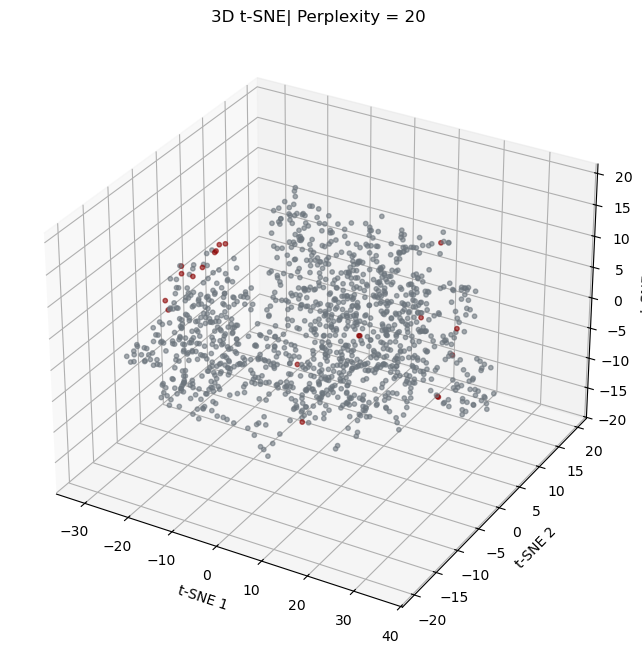

In [60]:
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)

coords_3d = TSNE(n_components=3, perplexity=20, random_state=42).fit_transform(numeric_scaled)

lof_3d = LocalOutlierFactor(n_neighbors=20)
scores_3d = -lof.fit_predict(numeric_scaled)
outlier_score_3d = -lof.negative_outlier_factor_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

base_cmap = mpl.colormaps["Reds"]

cmap = LinearSegmentedColormap.from_list("gray_strong_red", ["#6c757d", "#8B0000"])

ax.scatter(
    coords_3d[:, 0],
    coords_3d[:, 1],
    coords_3d[:, 2],
    c=scores_3d,
    cmap=cmap,
    s=10,
    alpha=0.6
)

ax.set_title(f"3D t-SNE| Perplexity = 20")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.savefig("tsne_3d_plot.png", dpi=300, bbox_inches='tight')
plt.show()

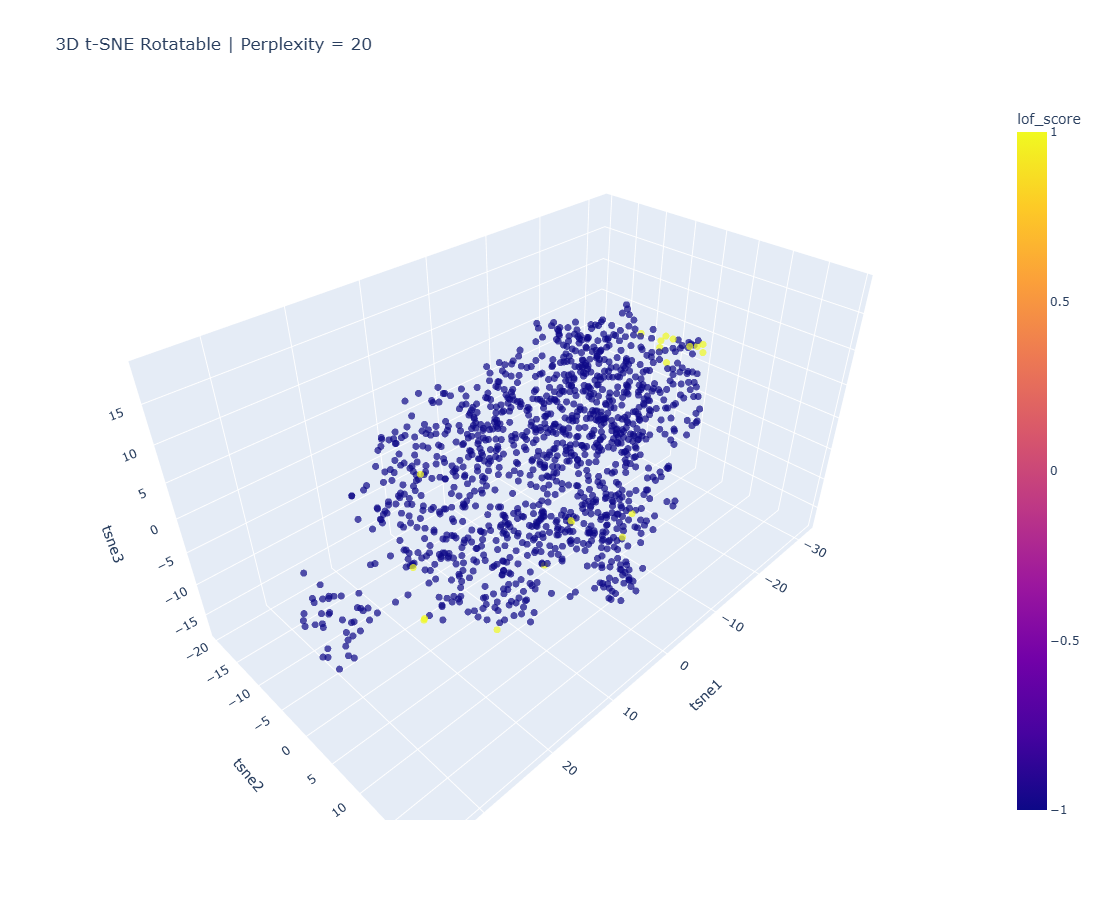

In [35]:
plot_df = pd.DataFrame(coords_3d, columns=["tsne1", "tsne2", "tsne3"], index=numeric_df.index)
plot_df["lof_score"] = scores_3d

cols_to_hover = [
    "score",
    "shots",
    "saves",
    "goals",
    "shots conceded",
    "avg speed",
    "count powerslide",
    "percentage high in air",
    "avg distance to ball no possession"
]

plot_df = pd.concat([plot_df, numeric_df[cols_to_hover]], axis=1)

fig = px.scatter_3d(
    plot_df,
    x="tsne1",
    y="tsne2",
    z="tsne3",
    color="lof_score",
    color_continuous_scale="Plasma",
    opacity=0.7,
    hover_data=["lof_score"] + cols_to_hover,
    title=f"3D t-SNE Rotatable | Perplexity = 20",
    width=1200,
    height=900
)

fig.update_traces(marker=dict(size=4))
fig.write_json("tsne_plot_rotate.json")
fig.show()

<p><span style="color:green; font-weight:bold">Below we can view the behavior of the new features added to the feature set (lof_score, clusters).</span></p>

In [36]:
suspects = master_tsne.nsmallest(50, 'lof_score')
suspects

,replay_id,playlist,rank,color,player name,platform,player id,car name,demos taken,car id,...,time neutral third,percentage neutral third,time offensive third,percentage offensive third,demos inflicted,smurf,tsne_1,tsne_2,lof_score,cluster
31,77fb842b-faa2-4efb-bbd0-e0edbd6e3b99,ranked-doubles,bronze,orange,Orangesig32,Epic,1e9b7c9e60e6404786a7ba56d9bbad52,Fennec,0,4284,...,0.00,0.00,0.00,0.00,0,0,-62.608734,-20.215141,-3.218229,0
555,72c0aabc-d482-40d0-8e4a-0d7aa491e700,ranked-doubles,gold,orange,DR.J,Psynet,24dc0f85ad08b1bb,Dominus,0,403,...,0.00,0.00,0.00,0.00,0,0,-66.517632,-8.858669,-2.214686,0
788,6b7ac4b2-5ee6-42a2-9682-d99572d8d489,ranked-doubles,platinum,blue,rage10b,Steam,76561198841096308,Octane,0,23,...,102.91,26.81,144.11,37.54,10,0,54.452133,5.534433,-1.882473,3
15,3a371ff8-84c4-46aa-86d3-7f750e1ae64b,ranked-doubles,bronze,orange,SimilarPerch5471,PS4,SimilarPerch5471,Dominus,1,403,...,100.80,26.18,61.05,15.85,1,0,4.014701,36.911674,-1.876301,4
105,0ed54d94-599d-48e7-8915-33f0fd5d4452,ranked-doubles,bronze,blue,lxstomania,Epic,83946706c682428c9a1633419ba94952,Fennec,0,4284,...,2.41,14.80,6.08,37.35,0,0,-43.055485,-12.397932,-1.746298,0
819,fe77ce49-2f20-463f-bf3e-b083b52e8a07,ranked-doubles,platinum,orange,rage10b,Steam,76561198841096308,Octane,0,23,...,116.64,27.07,126.07,29.26,7,0,54.450348,5.535207,-1.712368,3
55,258e20df-e961-49d7-a8c8-dcd2a685e4ee,ranked-doubles,bronze,orange,mOonliGht-dRiPz,PS4,mOonliGht-dRiPz,Octane,0,23,...,1.84,4.78,0.00,0.00,0,0,-67.010513,-18.210745,-1.643131,0
1023,a1ffb819-0be3-4a83-9b80-f535b8961179,ranked-doubles,silver,orange,C.Reach_Around,Epic,12d18acb686a402caec3a5a1cc0aee22,Fennec,0,4284,...,26.01,24.84,47.33,45.20,0,0,-64.676308,-7.007390,-1.638559,0
982,ef487f82-b3ce-4917-bea8-d8fdaef9e9f3,ranked-doubles,platinum,orange,syn_8554,PS4,syn_8554,Dominus,0,403,...,120.98,29.68,90.94,22.31,0,0,-30.564150,15.305655,-1.588280,1
477,da71254f-8dd7-49de-902e-0a4c179d8dcf,ranked-doubles,gold,blue,RL DADLESS,Epic,1fe7e6dce31b45e984f89663f6bba597,Octane,0,23,...,4.72,4.76,5.90,5.96,0,0,-66.335335,-10.110542,-1.587001,0


In [37]:
suspects['rank'].value_counts()

rank
bronze               14
gold                 13
platinum             10
silver                7
supersonic-legend     4
grand-champion        1
champion              1
Name: count, dtype: int64

<h2><span style="color:blue; font-weight:bold"><u>Classification</u></span></h2>
<p><span style="color:green; font-weight:bold">Now that we have additional features in outlier scores and clustering calculations, we can start trying to predict smurf likelihood.</span></p>

In [38]:
X = master_tsne.select_dtypes(include=['number']).drop(columns=['smurf', 'car id', 'tsne_1', 'tsne_2'],errors='ignore')
y = master_tsne['smurf']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [39]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, scale_pos_weight=scale_pos_weight)
xgb_model.fit(X_train, y_train)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [40]:
y_pred = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred))
check = pd.DataFrame({
    'true': y_test,
    'prob': y_prob,
    'pred': y_pred
}).sort_values('prob', ascending=False)
print(check)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       242
           1       0.70      0.70      0.70        10

    accuracy                           0.98       252
   macro avg       0.84      0.84      0.84       252
weighted avg       0.98      0.98      0.98       252

      true      prob  pred
876      1  0.997253     1
868      1  0.996541     1
980      1  0.989719     1
962      1  0.955032     1
1060     0  0.923976     1
...    ...       ...   ...
123      0  0.000053     0
95       0  0.000050     0
773      0  0.000049     0
1258     0  0.000046     0
987      0  0.000038     0

[252 rows x 3 columns]


In [41]:
check[check['true']==1]

,true,prob,pred
876,1,0.997253,1
868,1,0.996541,1
980,1,0.989719,1
962,1,0.955032,1
1184,1,0.763144,1
1178,1,0.625003,1
902,1,0.355567,1
892,1,0.001778,0
1190,1,0.001494,0
1194,1,0.001221,0


In [42]:
check[(check['true']==0) & (check['pred'] == 1)]

,true,prob,pred
1060,0,0.923976,1
662,0,0.834753,1
134,0,0.588163,1


In [43]:
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

score                           0.405977
shots conceded                  0.102362
amount stolen                   0.077770
percentage high in air          0.051523
time boost speed                0.042124
goals                           0.033806
lof_score                       0.032930
time on ground                  0.022845
avg distance to ball            0.020028
amount used while supersonic    0.016000
dtype: float32


<p><span style="color:green; font-weight:bold">From the above results we can see that are model is able to predict most smurf cases but still misses one. From the precision score we can see that we have some false identifiers, from the recall we can see that we are missing true positives, and the F1 score tells us we generally have room to grow. However, this is a good starting point for our model/scenario and we also got a glimpse into the influence of our top features.</span></p>

<p><span style="color:green; font-weight:bold">Now we are going to cross-validate and tune our model. For validation we will use a Stratified k-Fold to address the massive class-imbalance in our data. To tune the multiple parameters of our XGBClassifier, we will use Random Grid Search to efficiently search for a high-performing combination.</span></p>

In [44]:
cv_k = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model_test = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, scale_pos_weight=scale_pos_weight)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model_test,
    param_distributions=param_grid,
    n_iter=25,
    scoring='average_precision',
    cv=cv_k,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X, y)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.03, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [45]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
0.8555797721292375


<h3><span style="color:blue; font-weight:bold">Optimized Model and Threshold Determination</span></h3>

<p><span style="color:green; font-weight:bold">After our Random Grid Search and cross-validation, we have found our optimized parameters to tune a final run of the model. We will use these in an optimized model to create our probability calculations. We will then identify the proper likelihood threshold for our data.</span></p>

In [46]:
tuned_model = random_search.best_estimator_
tuned_model.fit(X_train, y_train)

final_prob = tuned_model.predict_proba(X_test)[:,1]

In [47]:
thresholds = np.linspace(0.01, 0.5, 30)

results = []

for t in thresholds:
    y_pred = (final_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append((t, precision, recall, f1))

for r in results:
    print('Threshold Value: ', r[0], ', Precision: ', r[1], ', Recall: ', r[2], ', F1: ', r[3])

Threshold Value:  0.01 , Precision:  0.3333333333333333 , Recall:  0.7 , F1:  0.45161290322580644
Threshold Value:  0.026896551724137928 , Precision:  0.4666666666666667 , Recall:  0.7 , F1:  0.56
Threshold Value:  0.04379310344827586 , Precision:  0.5384615384615384 , Recall:  0.7 , F1:  0.6086956521739131
Threshold Value:  0.060689655172413794 , Precision:  0.5833333333333334 , Recall:  0.7 , F1:  0.6363636363636364
Threshold Value:  0.07758620689655171 , Precision:  0.6363636363636364 , Recall:  0.7 , F1:  0.6666666666666666
Threshold Value:  0.09448275862068964 , Precision:  0.6363636363636364 , Recall:  0.7 , F1:  0.6666666666666666
Threshold Value:  0.11137931034482758 , Precision:  0.6363636363636364 , Recall:  0.7 , F1:  0.6666666666666666
Threshold Value:  0.12827586206896552 , Precision:  0.7 , Recall:  0.7 , F1:  0.7
Threshold Value:  0.14517241379310344 , Precision:  0.7 , Recall:  0.7 , F1:  0.7
Threshold Value:  0.16206896551724137 , Precision:  0.7 , Recall:  0.7 , F1:  

<p><span style="color:green; font-weight:bold">After running a short cross-validation of threshold values, using our predicted probabilities, we can determine that a threshold of 0.13 probability is acceptable relative to the data at hand. We determine this using our precision, recall, and F1 scores.</span></p>

<p><span style="color:green; font-weight:bold">Now we will run the threshold again to evaluate the final performance of the model.</span></p>

In [48]:
final_pred = (y_prob >= 0.13).astype(int)
print(classification_report(y_test, final_pred))
check = pd.DataFrame({
    'true': y_test,
    'prob': y_prob,
    'pred': final_pred
}).sort_values('prob', ascending=False)
print(check)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       242
           1       0.64      0.70      0.67        10

    accuracy                           0.97       252
   macro avg       0.81      0.84      0.83       252
weighted avg       0.97      0.97      0.97       252

      true      prob  pred
876      1  0.997253     1
868      1  0.996541     1
980      1  0.989719     1
962      1  0.955032     1
1060     0  0.923976     1
...    ...       ...   ...
123      0  0.000053     0
95       0  0.000050     0
773      0  0.000049     0
1258     0  0.000046     0
987      0  0.000038     0

[252 rows x 3 columns]


In [49]:
check[check['true']==1]

,true,prob,pred
876,1,0.997253,1
868,1,0.996541,1
980,1,0.989719,1
962,1,0.955032,1
1184,1,0.763144,1
1178,1,0.625003,1
902,1,0.355567,1
892,1,0.001778,0
1190,1,0.001494,0
1194,1,0.001221,0


In [50]:
check[(check['true']==0) & (check['pred'] == 1)]

,true,prob,pred
1060,0,0.923976,1
662,0,0.834753,1
134,0,0.588163,1
984,0,0.257311,1


In [51]:
importance = pd.Series(tuned_model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

score                                 0.164543
time defensive third                  0.127790
goals                                 0.103800
shots                                 0.077857
goals conceded                        0.047510
percentage offensive third            0.041365
goals conceded while last defender    0.036084
lof_score                             0.032795
shots conceded                        0.029029
percentage high in air                0.025142
dtype: float32


<p><span style="color:green; font-weight:bold">The above results review improved performance from the original run of the model. The combination of our optimized parameters and threshold have allowed us to identify all smurfs within the test split at high performance scores. The only caviat is that we have some false identifications of non-smurf players, but given the set of non-smurfs to be over 200, three false identifications is acceptable. Additionally, we can also view the tuned model's mindset of most influential statistics.</span></p>

<h3><span style="color:blue; font-weight:bold">Modeling Results Exploration and Visualizations</span></h3>

<p><span style="color:green; font-weight:bold">Below we compare our modeling results to identify the difference in behavior of our True Positives, False Positives, and False Positives. We also take a look at each specific player predicted. Following this exploration we create some additional visualizations of our most influential features.</span></p>

In [52]:
temp_1 = check[check['true']==1]
temp_2 = check[(check['true']==0) & (check['pred'] == 1)]
temp_comb = pd.concat([temp_1, temp_2])

temp_numeric_data = numeric_df.loc[temp_comb.index, cols_to_hover]
temp_meta_data = meta_df.loc[temp_comb.index, ['player id', 'car name']]

investigate_df = pd.concat([temp_comb, temp_numeric_data], axis=1)
investigate_df.to_json("prediction_statistics.json", orient="index")

In [53]:
investigate_df

,true,prob,pred,score,shots,saves,goals,shots conceded,avg speed,count powerslide,percentage high in air,avg distance to ball no possession
876,1,0.997253,1,1062,9,1,7,2,1389,56,1.26,2479
868,1,0.996541,1,1092,11,1,5,2,1636,52,7.84,2759
980,1,0.989719,1,1270,7,3,6,3,1538,58,9.49,2031
962,1,0.955032,1,1433,12,2,8,3,1616,39,6.99,2881
1184,1,0.763144,1,1030,6,1,4,4,1540,33,6.45,2122
1178,1,0.625003,1,1181,6,2,6,4,1574,64,8.53,2544
902,1,0.355567,1,869,6,1,5,4,1462,30,3.28,2302
892,1,0.001778,0,694,4,1,3,6,1543,106,7.35,2796
1190,1,0.001494,0,655,5,0,4,4,1400,31,8.46,2382
1194,1,0.001221,0,647,5,2,2,6,1442,117,2.70,2198


In [55]:
tp = check[(check['true'] == 1) & (check['pred'] == 1)]
fn = check[(check['true'] == 1) & (check['pred'] == 0)]
fp = check[(check['true'] == 0) & (check['pred'] == 1)]
tn = check[(check['true'] == 0) & (check['pred'] == 0)]

summary = pd.DataFrame({
    'TP': numeric_df.loc[tp.index, cols_to_hover].mean(),
    'FN': numeric_df.loc[fn.index, cols_to_hover].mean(),
    'FP': numeric_df.loc[fp.index, cols_to_hover].mean(),
    'TN': numeric_df.loc[tn.index, cols_to_hover].mean()
})

summary.columns = ['True Positive', 'False Negative', 'False Positive', 'True Negative']
summary = summary.round(2)
summary.to_json("prediction_summary.json", orient="index")
summary

,True Positive,False Negative,False Positive,True Negative
score,1133.86,665.33,1010.75,399.55
shots,8.14,4.67,8.25,2.92
saves,1.57,1.00,1.25,1.15
goals,5.86,3.00,5.50,1.34
shots conceded,3.14,5.33,6.75,6.18
avg speed,1536.43,1461.67,1456.75,1418.39
count powerslide,47.43,84.67,42.25,32.05
percentage high in air,6.26,6.17,5.37,3.17
avg distance to ball no possession,2445.43,2458.67,2460.25,2577.45


In [56]:
df_compare = master_df.copy()

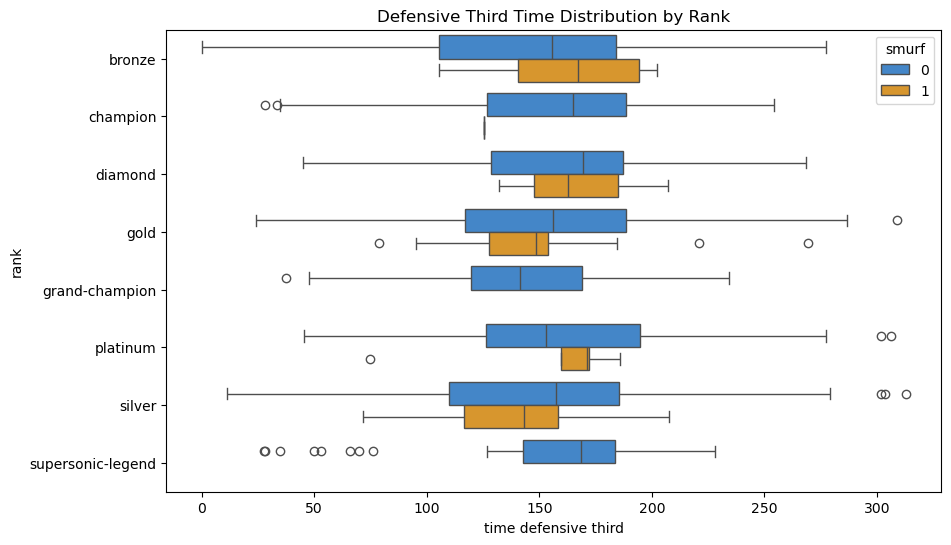

In [57]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_compare,
    x='time defensive third',
    y='rank',
    hue='smurf',
    palette={0: "#2E86DE", 1: "#F39C12"}
)

plt.title("Defensive Third Time Distribution by Rank")
plt.savefig("defensive_third_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

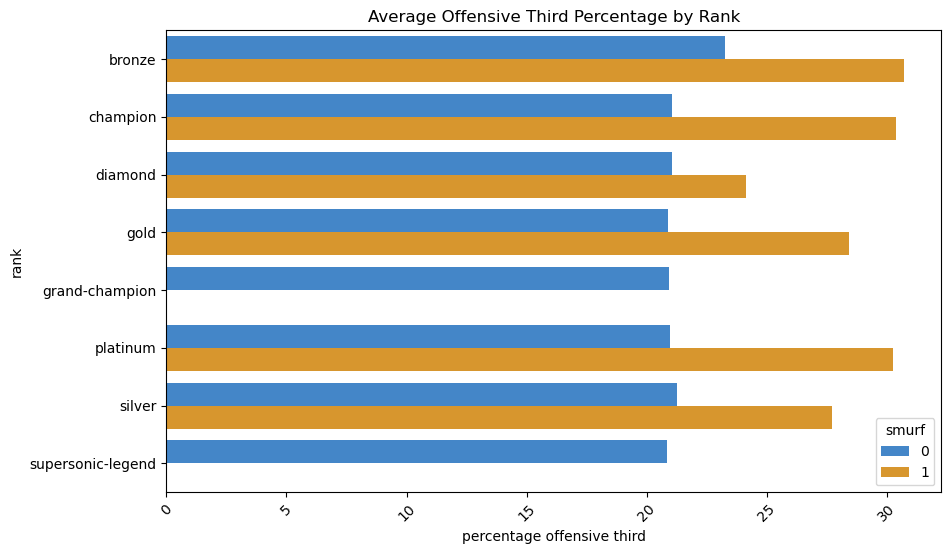

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_compare,
    x='percentage offensive third',
    y='rank',
    hue='smurf',
    palette={0: "#2E86DE", 1: "#F39C12"},
    errorbar=None
)

plt.title("Average Offensive Third Percentage by Rank")
plt.xticks(rotation=45)
plt.savefig("offensive_third_barplot.png", dpi=300, bbox_inches='tight')
plt.show()